In [106]:
import pandas as pd
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier 
from sklearn.model_selection import train_test_split 
from sklearn import metrics 
import seaborn as sns
import matplotlib.pyplot as plt

In [107]:
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
# load dataset
pima = pd.read_csv('/Users/eduardo/Desktop/Python_Coding/Applied-Data-Science-Classes/Machine Learning/diabetes.csv', header = 0, names=col_names)

### Dataset Preview
This shows the first few rows of the diabetes dataset so we can inspect the available variables.

In [108]:
pima.head()

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [109]:
#split dataset in features and target variable
feature_cols = ['pregnant', 'insulin', 'bmi', 'age','glucose','bp','pedigree']
X = pima[feature_cols] # Features
y = pima.label # Target variable

### Feature Correlations
This heatmap highlights how the input variables relate to one another before modeling.

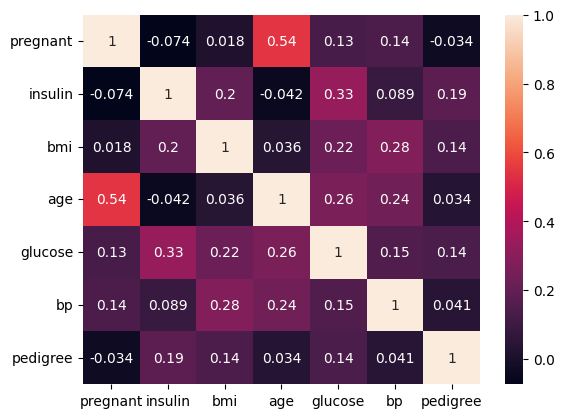

In [110]:
corr = X.corr()

sns.heatmap(corr, annot=True)
plt.show()

In [111]:
# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1) # 70% training and 30% test

In [112]:
# Create Decision Tree classifer object
clf = tree.DecisionTreeClassifier()

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

### Decision Tree Accuracy
This prints the baseline accuracy of a single decision tree on the test set.

In [113]:
# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.6883116883116883


### Tree Structure
This plot visualizes the splits learned by the decision tree classifier.

[Text(0.403125, 0.96875, 'x[4] <= 129.5\ngini = 0.449\nsamples = 537\nvalue = [354, 183]'),
 Text(0.146875, 0.90625, 'x[2] <= 26.3\ngini = 0.329\nsamples = 357\nvalue = [283, 74]'),
 Text(0.044444444444444446, 0.84375, 'x[2] <= 9.1\ngini = 0.06\nsamples = 97\nvalue = [94, 3]'),
 Text(0.022222222222222223, 0.78125, 'x[0] <= 7.5\ngini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.011111111111111112, 0.71875, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.03333333333333333, 0.71875, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.06666666666666667, 0.78125, 'x[6] <= 0.669\ngini = 0.022\nsamples = 91\nvalue = [90, 1]'),
 Text(0.05555555555555555, 0.71875, 'gini = 0.0\nsamples = 76\nvalue = [76, 0]'),
 Text(0.07777777777777778, 0.71875, 'x[6] <= 0.705\ngini = 0.124\nsamples = 15\nvalue = [14, 1]'),
 Text(0.06666666666666667, 0.65625, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.08888888888888889, 0.65625, 'gini = 0.0\nsamples = 14\nvalue = [14, 0]'),
 Text(0.24930555555555

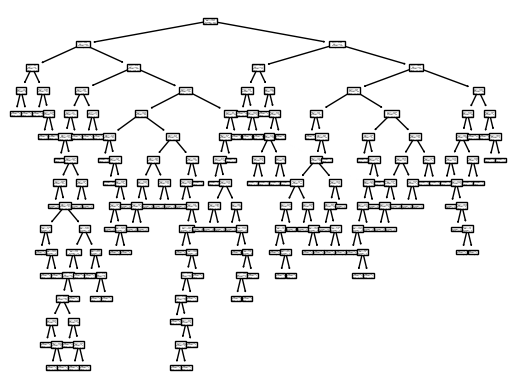

In [114]:
tree.plot_tree(clf) 

### Ensemble Comparison
Here we compare bagging and random forest to see whether ensembles outperform a single tree.

In [115]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

# Compare two ensemble methods on the same train/test split
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=1
)

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=1
)

bagging_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

bagging_pred = bagging_model.predict(X_test)
random_forest_pred = random_forest_model.predict(X_test)

comparison = pd.DataFrame({
    'Model': ['Bagging', 'Random Forest'],
    'Accuracy': [
        metrics.accuracy_score(y_test, bagging_pred),
        metrics.accuracy_score(y_test, random_forest_pred)
    ]
})

print(comparison)

           Model  Accuracy
0        Bagging  0.787879
1  Random Forest  0.787879


### Linear Models And SVM
This table compares OLS, Ridge, Lasso, Logistic Regression, and SVM on the same test split.

In [116]:
from sklearn.linear_model import Lasso, LinearRegression, LogisticRegression, Ridge
from sklearn.svm import SVC

# Fit linear and logistic models, then compare test accuracy
ols_model = LinearRegression()
ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=0.01, max_iter=10000)
logistic_model = LogisticRegression(max_iter=10000)
svm_model = SVC()

ols_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)
logistic_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)

ols_pred = (ols_model.predict(X_test) >= 0.5).astype(int)
ridge_pred = (ridge_model.predict(X_test) >= 0.5).astype(int)
lasso_pred = (lasso_model.predict(X_test) >= 0.5).astype(int)
logistic_pred = logistic_model.predict(X_test)
svm_pred = svm_model.predict(X_test)

linear_comparison = pd.DataFrame({
    'Model': ['OLS', 'Ridge', 'Lasso', 'Logistic Regression', 'SVM'],
    'Accuracy': [
        metrics.accuracy_score(y_test, ols_pred),
        metrics.accuracy_score(y_test, ridge_pred),
        metrics.accuracy_score(y_test, lasso_pred),
        metrics.accuracy_score(y_test, logistic_pred),
        metrics.accuracy_score(y_test, svm_pred)
    ]
})

print(linear_comparison.sort_values(by='Accuracy', ascending=False).reset_index(drop=True))

                 Model  Accuracy
0                Lasso  0.787879
1  Logistic Regression  0.783550
2                  OLS  0.779221
3                Ridge  0.779221
4                  SVM  0.766234


### Confusion Matrices
These confusion matrices show where each model makes correct predictions and mistakes.

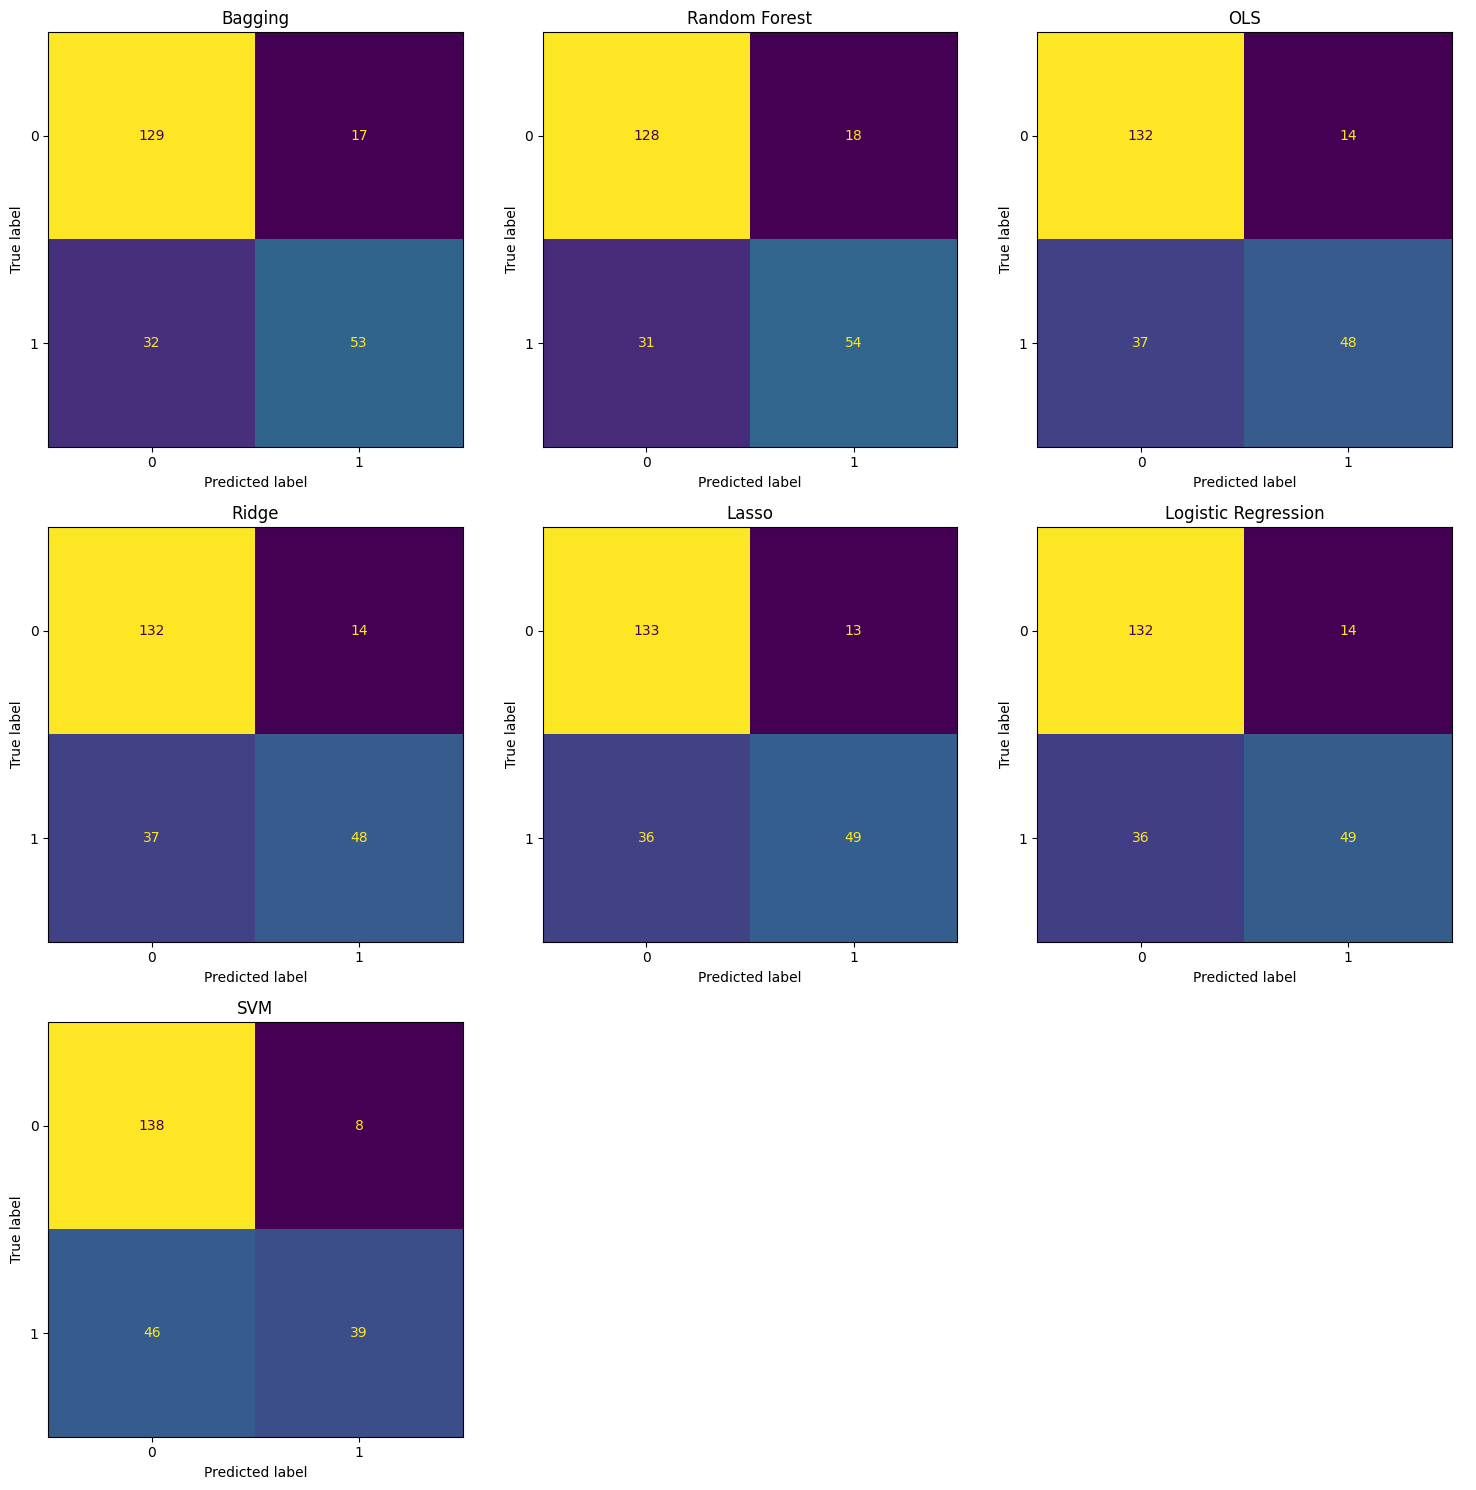

In [117]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

model_predictions = {
    'Bagging': bagging_pred,
    'Random Forest': random_forest_pred,
    'OLS': ols_pred,
    'Ridge': ridge_pred,
    'Lasso': lasso_pred,
    'Logistic Regression': logistic_pred,
    'SVM': svm_pred
}

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for ax, (model_name, predictions) in zip(axes.ravel(), model_predictions.items()):
    cm = confusion_matrix(y_test, predictions)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax, colorbar=False)
    ax.set_title(model_name)

for ax in axes.ravel()[len(model_predictions):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

### Original Feature Importance
This figure summarizes which original variables matter most for each model.

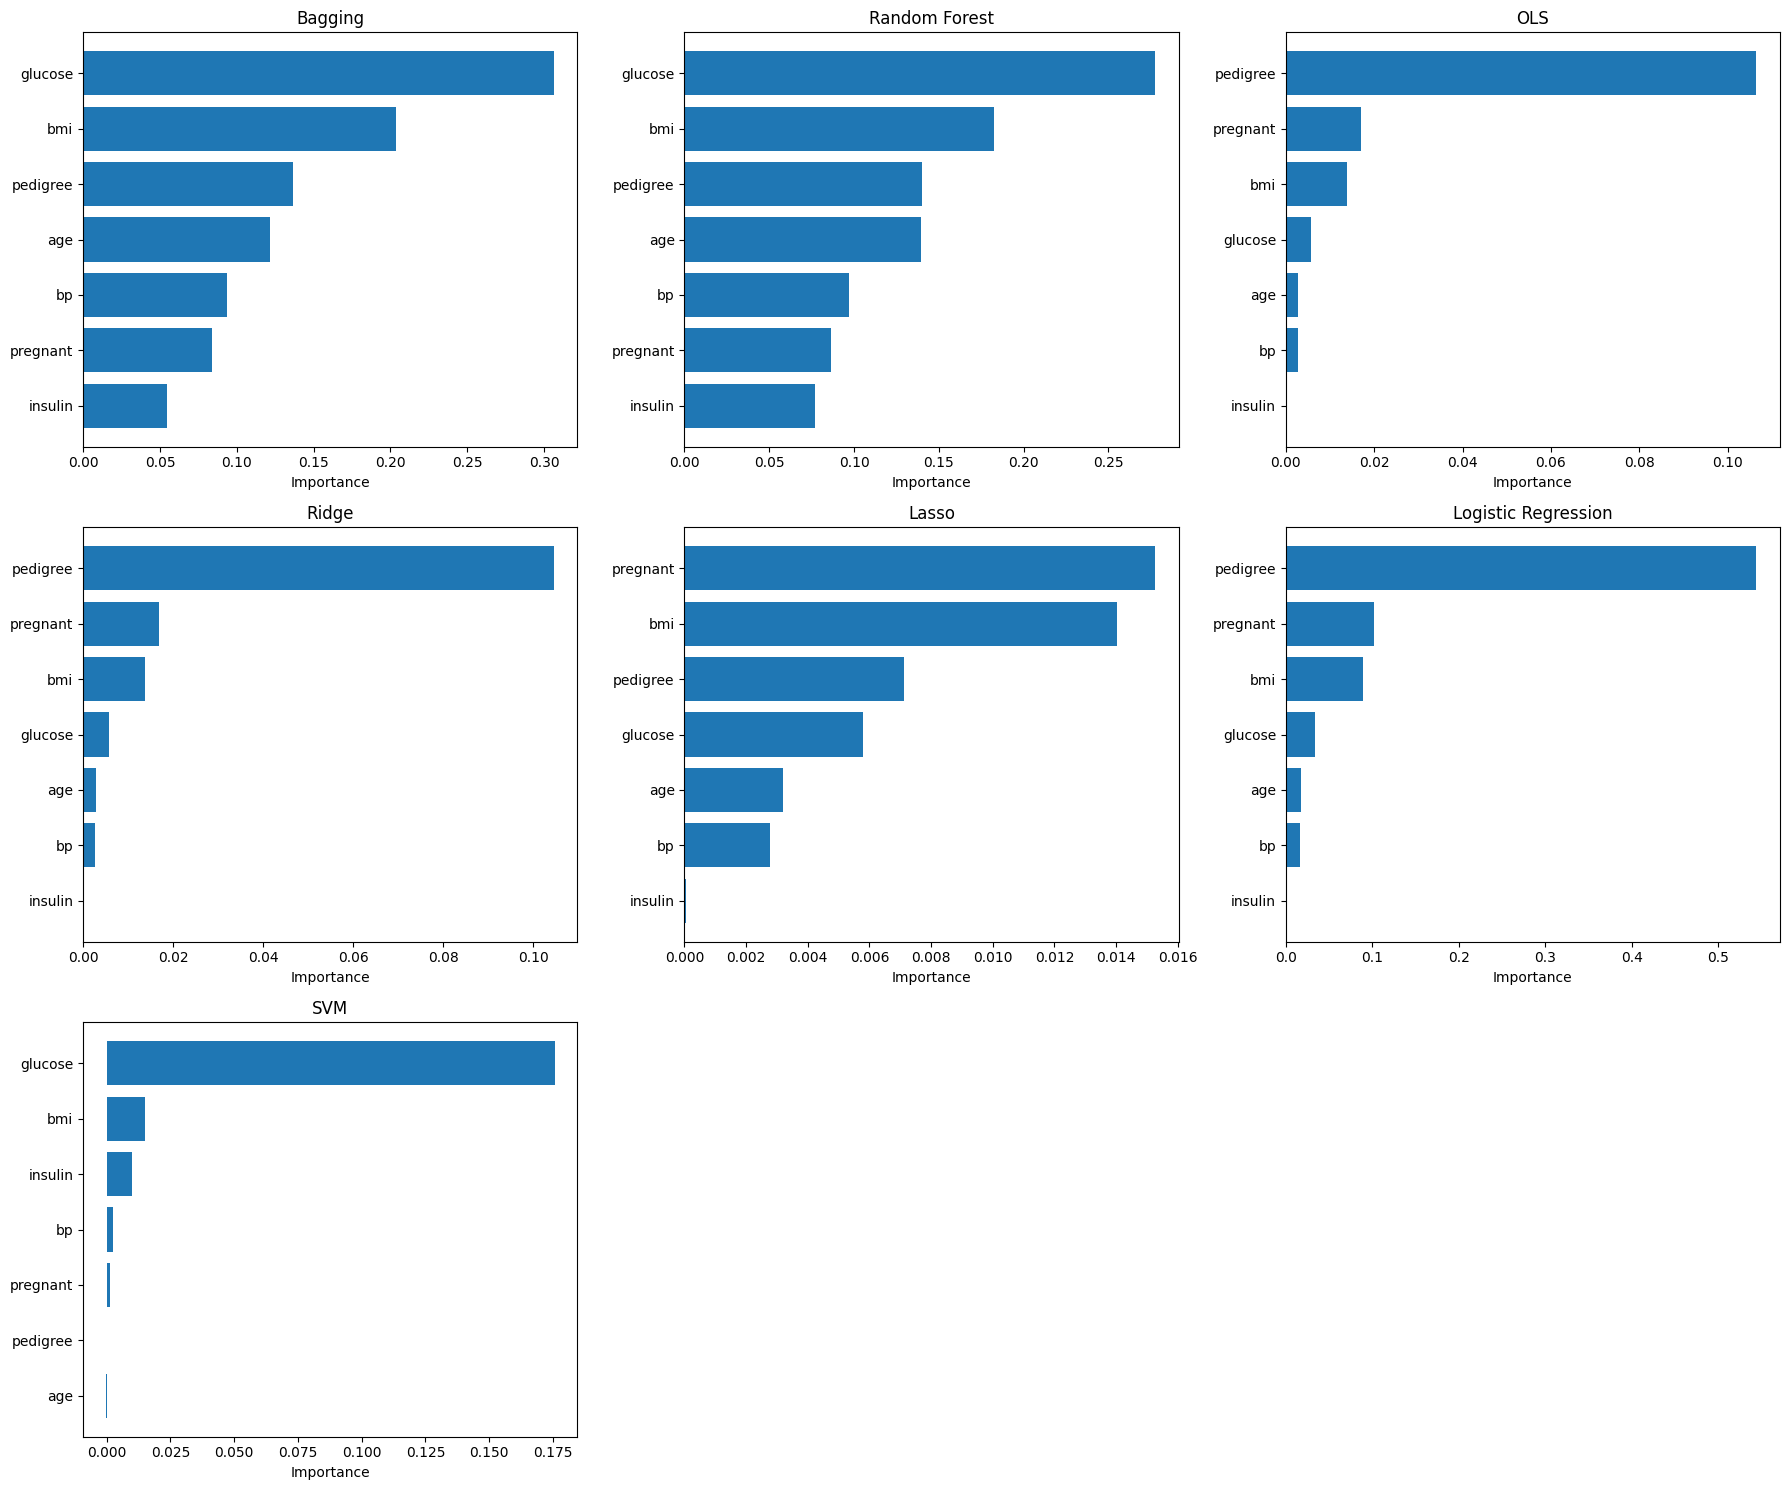

In [118]:
from sklearn.inspection import permutation_importance
import numpy as np

importance_data = {
    'Bagging': np.mean([est.feature_importances_ for est in bagging_model.estimators_], axis=0),
    'Random Forest': random_forest_model.feature_importances_,
    'OLS': np.abs(ols_model.coef_),
    'Ridge': np.abs(ridge_model.coef_),
    'Lasso': np.abs(lasso_model.coef_),
    'Logistic Regression': np.abs(logistic_model.coef_[0]),
    'SVM': permutation_importance(svm_model, X_test, y_test, n_repeats=10, random_state=1).importances_mean
}

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for ax, (model_name, importance_values) in zip(axes.ravel(), importance_data.items()):
    importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': importance_values
    }).sort_values(by='Importance', ascending=True)

    ax.barh(importance_df['Feature'], importance_df['Importance'])
    ax.set_title(model_name)
    ax.set_xlabel('Importance')

for ax in axes.ravel()[len(importance_data):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

### OLS Feature Engineering Test
This experiment checks whether simple combined features improve OLS classification accuracy.

In [119]:
# Try a few engineered features with OLS and compare test accuracy
engineered_features_train = {
    'glucose_bmi_interaction': X_train['glucose'] * X_train['bmi'],
    'age_bmi_interaction': X_train['age'] * X_train['bmi'],
    'pregnancy_age_interaction': X_train['pregnant'] * X_train['age'],
    'glucose_insulin_ratio': X_train['glucose'] / (X_train['insulin'] + 1),
    'bmi_bp_ratio': X_train['bmi'] / (X_train['bp'] + 1),
    'risk_score': X_train['glucose'] + X_train['bmi'] + X_train['age']
}

engineered_features_test = {
    'glucose_bmi_interaction': X_test['glucose'] * X_test['bmi'],
    'age_bmi_interaction': X_test['age'] * X_test['bmi'],
    'pregnancy_age_interaction': X_test['pregnant'] * X_test['age'],
    'glucose_insulin_ratio': X_test['glucose'] / (X_test['insulin'] + 1),
    'bmi_bp_ratio': X_test['bmi'] / (X_test['bp'] + 1),
    'risk_score': X_test['glucose'] + X_test['bmi'] + X_test['age']
}

feature_engineering_results = []

baseline_ols = LinearRegression()
baseline_ols.fit(X_train, y_train)
baseline_pred = (baseline_ols.predict(X_test) >= 0.5).astype(int)
baseline_accuracy = metrics.accuracy_score(y_test, baseline_pred)

feature_engineering_results.append({
    'Feature Set': 'Baseline features only',
    'Accuracy': baseline_accuracy
})

for feature_name in engineered_features_train:
    X_train_engineered = X_train.copy()
    X_test_engineered = X_test.copy()
    X_train_engineered[feature_name] = engineered_features_train[feature_name]
    X_test_engineered[feature_name] = engineered_features_test[feature_name]

    engineered_ols = LinearRegression()
    engineered_ols.fit(X_train_engineered, y_train)
    engineered_pred = (engineered_ols.predict(X_test_engineered) >= 0.5).astype(int)

    feature_engineering_results.append({
        'Feature Set': feature_name,
        'Accuracy': metrics.accuracy_score(y_test, engineered_pred)
    })

X_train_all_engineered = X_train.copy()
X_test_all_engineered = X_test.copy()

for feature_name in engineered_features_train:
    X_train_all_engineered[feature_name] = engineered_features_train[feature_name]
    X_test_all_engineered[feature_name] = engineered_features_test[feature_name]

all_engineered_ols = LinearRegression()
all_engineered_ols.fit(X_train_all_engineered, y_train)
all_engineered_pred = (all_engineered_ols.predict(X_test_all_engineered) >= 0.5).astype(int)

feature_engineering_results.append({
    'Feature Set': 'All engineered features',
    'Accuracy': metrics.accuracy_score(y_test, all_engineered_pred)
})

feature_engineering_df = pd.DataFrame(feature_engineering_results)
feature_engineering_df = feature_engineering_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
print(feature_engineering_df)

                 Feature Set  Accuracy
0  pregnancy_age_interaction  0.787879
1    All engineered features  0.787879
2      glucose_insulin_ratio  0.783550
3     Baseline features only  0.779221
4    glucose_bmi_interaction  0.779221
5        age_bmi_interaction  0.779221
6               bmi_bp_ratio  0.779221
7                 risk_score  0.779221


### Engineered Features In Tree Models And SVM
This table shows how the best engineered features affect tree-based models and SVM.

In [120]:
# Add only the most useful engineered features to tree models and SVM
selected_engineered_features = ['pregnancy_age_interaction', 'glucose_insulin_ratio']

tree_train_engineered = X_train.copy()
tree_test_engineered = X_test.copy()

for feature_name in selected_engineered_features:
    tree_train_engineered[feature_name] = engineered_features_train[feature_name]
    tree_test_engineered[feature_name] = engineered_features_test[feature_name]

decision_tree_engineered = DecisionTreeClassifier(random_state=1)
bagging_engineered = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=1
)
random_forest_engineered = RandomForestClassifier(
    n_estimators=100,
    random_state=1
)
svm_engineered = SVC()

decision_tree_engineered.fit(tree_train_engineered, y_train)
bagging_engineered.fit(tree_train_engineered, y_train)
random_forest_engineered.fit(tree_train_engineered, y_train)
svm_engineered.fit(tree_train_engineered, y_train)

tree_engineered_pred = decision_tree_engineered.predict(tree_test_engineered)
bagging_engineered_pred = bagging_engineered.predict(tree_test_engineered)
random_forest_engineered_pred = random_forest_engineered.predict(tree_test_engineered)
svm_engineered_pred = svm_engineered.predict(tree_test_engineered)

engineered_model_results = pd.DataFrame({
    'Model': ['Decision Tree + engineered features', 'Bagging + engineered features', 'Random Forest + engineered features', 'SVM + engineered features'],
    'Accuracy': [
        metrics.accuracy_score(y_test, tree_engineered_pred),
        metrics.accuracy_score(y_test, bagging_engineered_pred),
        metrics.accuracy_score(y_test, random_forest_engineered_pred),
        metrics.accuracy_score(y_test, svm_engineered_pred)
    ]
})

print(engineered_model_results.sort_values(by='Accuracy', ascending=False).reset_index(drop=True))

                                 Model  Accuracy
0        Bagging + engineered features  0.800866
1  Random Forest + engineered features  0.787879
2            SVM + engineered features  0.740260
3  Decision Tree + engineered features  0.705628


### Engineered Feature Importance
These plots show which original and engineered variables drive the updated tree models and SVM.

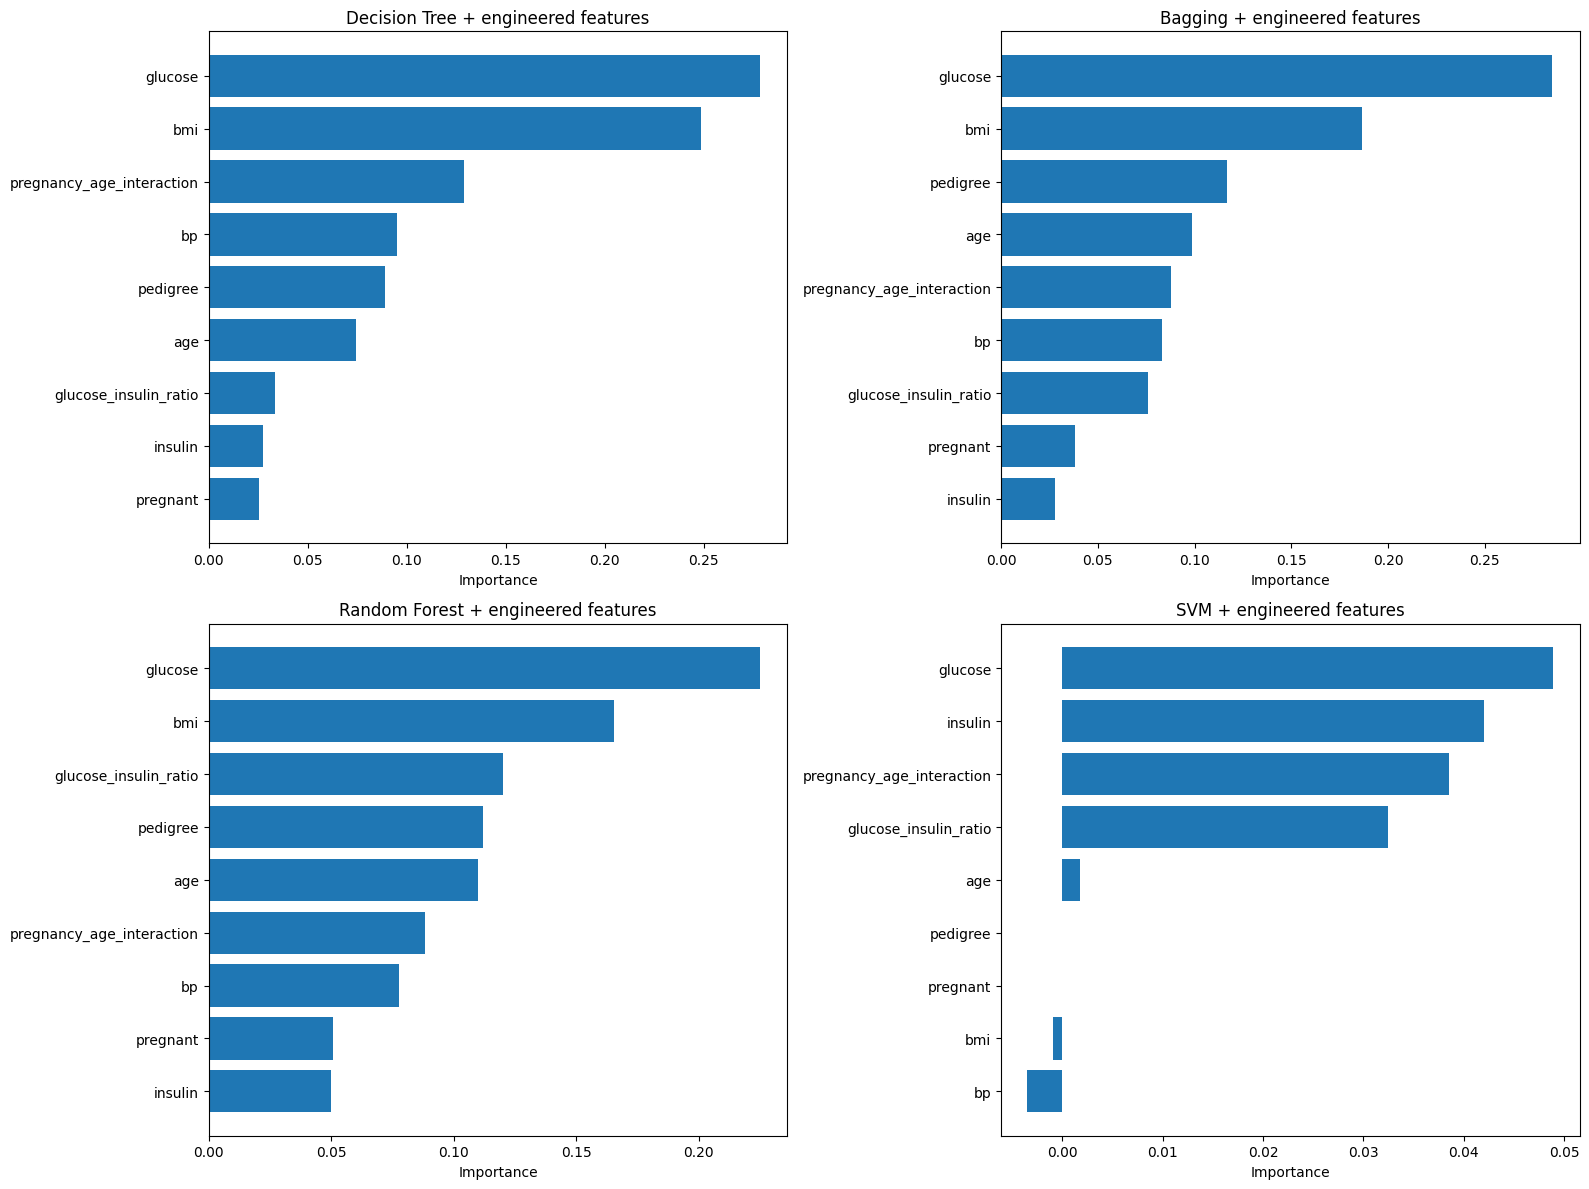

In [121]:
# Plot feature importance for the engineered-feature models
engineered_feature_names = feature_cols + selected_engineered_features

engineered_importance_data = {
    'Decision Tree + engineered features': decision_tree_engineered.feature_importances_,
    'Bagging + engineered features': np.mean([est.feature_importances_ for est in bagging_engineered.estimators_], axis=0),
    'Random Forest + engineered features': random_forest_engineered.feature_importances_,
    'SVM + engineered features': permutation_importance(
        svm_engineered,
        tree_test_engineered,
        y_test,
        n_repeats=10,
        random_state=1
    ).importances_mean
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, (model_name, importance_values) in zip(axes.ravel(), engineered_importance_data.items()):
    importance_df = pd.DataFrame({
        'Feature': engineered_feature_names,
        'Importance': importance_values
    }).sort_values(by='Importance', ascending=True)

    ax.barh(importance_df['Feature'], importance_df['Importance'])
    ax.set_title(model_name)
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [122]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Apply the boosting model used in GB Test.ipynb
gb_model = GradientBoostingClassifier(
    n_estimators=20,
    learning_rate=0.5,
    max_features=2,
    max_depth=2,
    random_state=0
)

gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

print('Gradient Boosting Accuracy:', metrics.accuracy_score(y_test, gb_pred))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, gb_pred))
print('\nClassification Report:')
print(classification_report(y_test, gb_pred))

Gradient Boosting Accuracy: 0.7835497835497836

Confusion Matrix:
[[132  14]
 [ 36  49]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       146
           1       0.78      0.58      0.66        85

    accuracy                           0.78       231
   macro avg       0.78      0.74      0.75       231
weighted avg       0.78      0.78      0.78       231

